In [39]:
import pandas as pd
import geopandas as gpd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

import utils.cross_validation as cval
import random 
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
import pandas as pd
import utils.eval_utils as ev
import shap
import numpy as np
from sklearn.inspection import partial_dependence
import utils.model_utils as mu
from sklearn.preprocessing import StandardScaler


In [40]:
def SHAP_plots(model_f, model_s, X_test_f, X_test_s, colour_f="#4b72f1", colour_s="#c88f8f"):
    
    explainer_f = shap.TreeExplainer(model_f)
    shap_values_f = explainer_f(X_test_f, approximate=True)
    
    explainer_s = shap.TreeExplainer(model_s)
    shap_values_s = explainer_s(X_test_s, approximate=True)

    fig, (ax_f, ax_s) = plt.subplots(1, 2, figsize=(14, 6))

    # ── Left: functional diversity ──
    plt.sca(ax_f)
    shap.plots.bar(shap_values_f.abs.mean(0), max_display=len(X_test_f.columns), show=False, ax=ax_f)
    for bar in ax_f.patches:
        bar.set_color(colour_f)
    ax_f.spines["right"].set_visible(True)
    ax_f.spines["left"].set_visible(True)

    # ── Right: species diversity — inverted ──
    plt.sca(ax_s)
    shap.plots.bar(shap_values_s.abs.mean(0), max_display=len(X_test_s.columns), show=False, ax=ax_s)
    for bar in ax_s.patches:
        bar.set_color(colour_s)
    ax_s.invert_xaxis()
    ax_s.yaxis.set_label_position("right")
    ax_s.yaxis.tick_right()
    ax_s.spines["right"].set_visible(True)
    ax_s.spines["left"].set_visible(True)
    for text in ax_s.texts:
        x, y = text.get_position()
        text.set_position((x + 0.03, y))

    # ── Align x axes ──
    max_val = max(ax_f.get_xlim()[1], ax_s.get_xlim()[0])  # ax_s is inverted so take [0]
    ax_f.set_xlim(0, max_val)
    ax_s.set_xlim(max_val, 0)  # inverted

    plt.tight_layout()
    plt.show()

    shap_df_f = pd.DataFrame(shap_values_f.values, columns=X_test_f.columns, index=X_test_f.index)
    shap_df_s = pd.DataFrame(shap_values_s.values, columns=X_test_s.columns, index=X_test_s.index)

    return shap_df_f, explainer_f, shap_df_s, explainer_s

def plot_pdp(div_f, div_s, fd_model, sd_model, fX_test, sX_test, name="pdp_plot.png"):

    paired_vars = list(zip(div_f, div_s))

    colors_f = "#0338f6"
    colors_s = "#c88f8f"

    # 2 rows x 3 cols
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes_flat = axes.flatten()  # flatten to iterate easily
    fig.subplots_adjust(hspace=0.6)  # increase from default ~0.2
    for ax, (f_var, s_var) in zip(axes_flat, paired_vars):

        pd_f = partial_dependence(fd_model, fX_test, features=[f_var], grid_resolution=200)
        pd_s = partial_dependence(sd_model, sX_test, features=[s_var], grid_resolution=200)

        x_f = pd_f["grid_values"][0]
        x_s = pd_s["grid_values"][0]
        y_f = pd_f["average"][0]
        y_s = pd_s["average"][0]

        # ── Bottom x-axis: species diversity ──
        ax.plot(x_s, y_s, color=colors_s, linewidth=2, linestyle="--")
        ax.set_xlabel(s_var)
        ax.tick_params(axis="x")

        # ── Top x-axis: functional diversity ──
        ax_top = ax.twiny()
        ax_top.plot(x_f, y_f, color=colors_f, linewidth=2)
        ax_top.set_xlabel(f_var)
        ax_top.tick_params(axis="x")

        # y label only on leftmost column
        ax.set_ylabel(" Influence on Predicted NPP" if ax in axes[:, 0] else "")
        ax.spines[["right"]].set_visible(False)
        ax_top.spines[["right"]].set_visible(False)
        

In [41]:
ecoregions=cval.process_ecoregion("data/Ecoregions/Ecoregions2017.shp")

ecoregions=ecoregions[['ECO_NAME', 'geometry']]

def data_preprocessing (df, random_key=42):
    #Preprocessing the data for Random forest regression

    # df = df[~df['biome'].isin([13, 1, 2, 3])]
    # df = df[df['biome'].isin([4])]

    # df["biome"] = df["biome"].replace(biome_mapping)

    df=cval.assign_spatial_groups(df, grid_size=1.0)

    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326"  # WGS84
    )

    joined = gpd.sjoin(gdf, ecoregions, how="left", predicate="within")

    X_train, y_train, X_test, y_test = train_test_split(joined, random_key)
    return X_train, y_train, X_test, y_test


def train_test_split(sub_df, random_key):
    sub_df = sub_df.drop(columns=['BHAGE', 'managed', 'ownership', 'geometry', 
                                   'index_right', 'lat', 'lon', 'DIA', 'TPA_UNADJ',
                                   'lon_bin', 'lat_bin', 'WSCI'])
    
    sets = list(set(sub_df['ECO_NAME']))
    set_b = list(set(sub_df['biome']))
    
    random.seed(random_key)
    
    test = []
    remaining_sets = sets.copy()
    n=0
    for biome in set_b:
            # Only consider candidates still in remaining_sets
            candidates = list(set(sub_df[sub_df['biome'] == biome]['ECO_NAME']) & set(remaining_sets))
            chosen = random.choice(candidates)
            test.append(chosen)
            remaining_sets.remove(chosen)
    
    test_set = sub_df[sub_df["ECO_NAME"].isin(test)]
    training_set = sub_df[~sub_df["ECO_NAME"].isin(test)]

    y=['transformed npp'] 

    X_train=training_set.drop(columns=y+['PID', 'spatial_group', 'ECO_NAME'])

    # X_train = X_train.drop(columns=['CHELSA_BIO_Annual_Mean_Temperature', 'CHELSA_BIO_Annual_Precipitation',
    #    'CHELSA_BIO_Precipitation_Seasonality',
    #    'CrowtherLab_SoilMoisture_intraAnnualSD_downsampled10km'])
    y_train = training_set['transformed npp'].values
  
    X_test= test_set.drop(columns=y+['PID', 'spatial_group', 'ECO_NAME'])

    # X_test = X_test.drop(columns=['CHELSA_BIO_Annual_Mean_Temperature', 'CHELSA_BIO_Annual_Precipitation',
    #    'CHELSA_BIO_Precipitation_Seasonality',
    #    'CrowtherLab_SoilMoisture_intraAnnualSD_downsampled10km'])

    y_test = test_set['transformed npp'].values


    scaler= StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

    return X_train, y_train, X_test, y_test

In [42]:
def quick_eval(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
    r2 = r2_score(y_test, y_pred, multioutput='raw_values')
    return mae, r2

In [43]:


fd_df= pd.read_csv("data/final/fd_df.csv")
sd_df = pd.read_csv("data/final/sd_df.csv")

ecoregions=cval.process_ecoregion("data/Ecoregions/Ecoregions2017.shp")

ecoregions=ecoregions[['ECO_NAME', 'geometry']]

fd_df = fd_df.loc[:, ~fd_df.columns.str.contains(r'\.1')]
sd_df = sd_df.loc[:, ~sd_df.columns.str.contains(r'\.1')]

fd_df.drop(columns=['Mean Pairwise D'], inplace=True)
fd_df.dropna(subset=['TPA_UNADJ'], inplace=True) # Maybe exclude

sd_df.dropna(subset=['TPA_UNADJ'], inplace=True) # Maybe exclude
# sd_df = sd_df[sd_df["WSCI"] >= -1000]
# fd_df = fd_df[fd_df["WSCI"] >= -1000]


sd_df.columns = sd_df.columns.str.replace('_x$', '', regex=True)
sd_df.columns = sd_df.columns.str.replace('_y$', '', regex=True)

sd_df = sd_df.loc[:, ~sd_df.columns.duplicated()]


shared_pids = set(sd_df["PID"]).intersection(fd_df["PID"])

# Filter both dataframes to only shared PIDs
sd_df = sd_df[sd_df["PID"].isin(shared_pids)]
fd_df = fd_df[fd_df["PID"].isin(shared_pids)]


In [44]:
RANDOM_KEY = 23

random.seed(RANDOM_KEY)

In [45]:
# sd_df.drop(columns=['WSCI', 'Max_DBH', 'GC'], inplace=True)
# fd_df.drop(columns=['WSCI', 'Max_DBH', 'GC'], inplace=True)

sX_train, sy_train, sX_test, sy_test = data_preprocessing(sd_df, RANDOM_KEY)
fX_train, fy_train, fX_test, fy_test = data_preprocessing(fd_df, RANDOM_KEY)


sd_reg=RandomForestRegressor(
    random_state=RANDOM_KEY, 
    n_jobs=4
)

fd_reg=RandomForestRegressor(
    random_state=RANDOM_KEY,
    n_jobs=4
)

sd_reg.fit(sX_train, sy_train)
fd_reg.fit(fX_train, fy_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [46]:
smae, sr2 = quick_eval(sd_reg, sX_test, sy_test)  
fmae, fr2 = quick_eval(fd_reg, fX_test, fy_test)

print(f"SD MAE: {smae}, SD R2: {sr2}")
print(f"FD MAE: {fmae}, FD R2: {fr2}")

SD MAE: [0.32292879], SD R2: [0.63970345]
FD MAE: [0.32143901], FD R2: [0.64332626]


In [48]:
sX_test.columns

Index(['CHELSA_BIO_Annual_Mean_Temperature', 'CHELSA_BIO_Annual_Precipitation',
       'CHELSA_BIO_Precipitation_Seasonality',
       'CrowtherLab_SoilMoisture_intraAnnualSD_downsampled10km',
       'SG_SOC_Content_015cm', 'EsaCci_BurntAreasProbability',
       'EarthEnvTopoMed_Elevation', 'EarthEnvTopoMed_Slope',
       'SG_Depth_to_bedrock', 'EarthEnvTopoMed_Northness', 'biome',
       'Species Richness', 'Shannon Diversity', 'Simpson's Index', 'GC',
       'Max_DBH'],
      dtype='str')

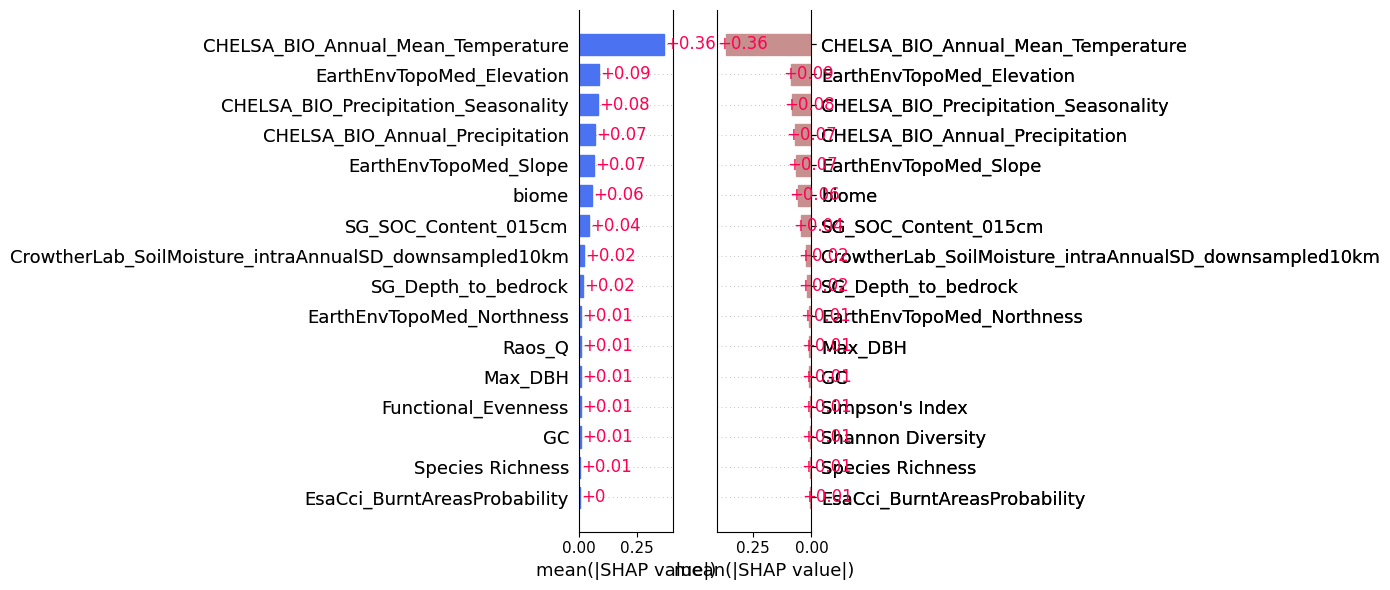

In [49]:
from sklearn.inspection import partial_dependence
import matplotlib.pyplot as plt


fshap_df, fexplainer, sshap_df, sexplainer = SHAP_plots(
    fd_reg, sd_reg, fX_test, sX_test
)



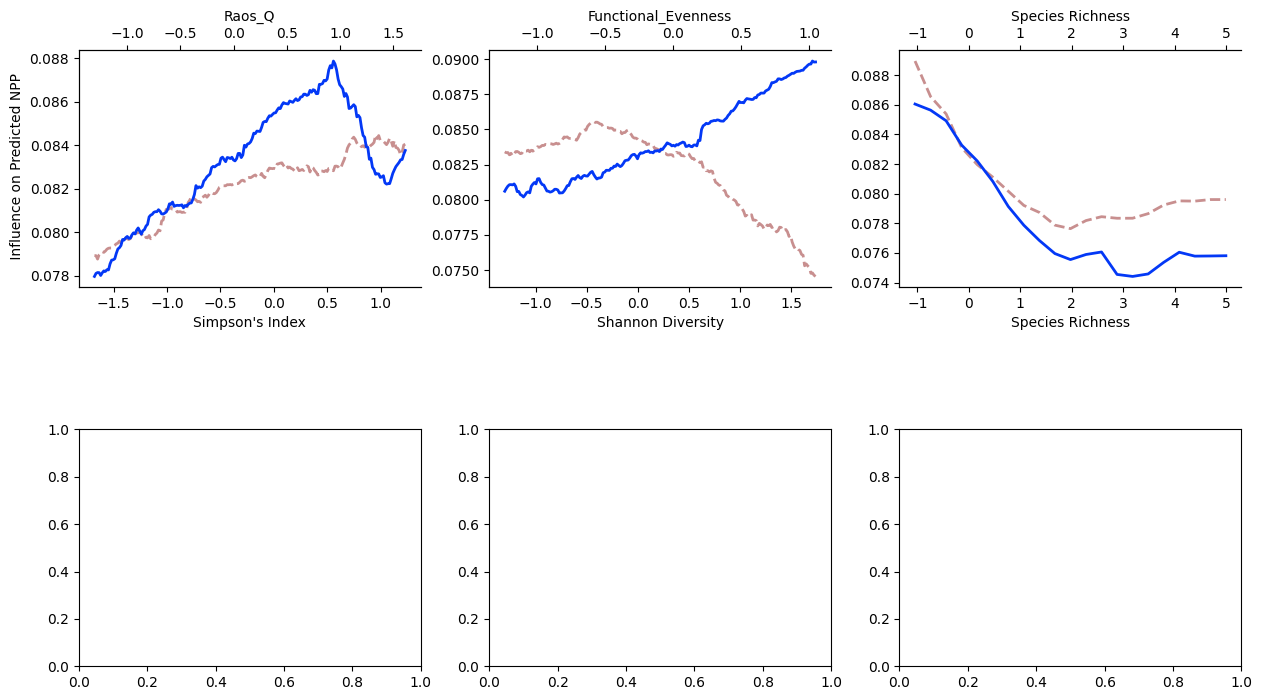

In [50]:
diversity_vars_f = ['Raos_Q', 'Functional_Evenness', 'Species Richness']
diversity_vars_s = ["Simpson's Index", 'Shannon Diversity', 'Species Richness']

plot_pdp(diversity_vars_f, diversity_vars_s, fd_reg, sd_reg, fX_test, sX_test, f"pdp_plot_{RANDOM_KEY}.png")


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

def plot_r2_heatmap(model, X_test, y_test, feature_x, feature_y, bins=20, cmap="RdYlGn"):
    """
    Plots a heatmap where colour = R² computed on samples
    falling within each (feature_x, feature_y) bin.
    """
    df = X_test.copy()
    df["_y_true"] = y_test.values if hasattr(y_test, "values") else y_test
    df["_y_pred"] = model.predict(X_test)

    # bin the two features
    df["_bin_x"] = pd.cut(df[feature_x], bins=bins)
    df["_bin_y"] = pd.cut(df[feature_y], bins=bins)

    # compute R² per bin
    def safe_r2(g):
        if len(g) < 2:
            return np.nan
        return r2_score(g["_y_true"], g["_y_pred"])

    r2_matrix = (
        df.groupby(["_bin_y", "_bin_x"], observed=True)
        .apply(safe_r2)
        .unstack("_bin_x")
    )

    # readable tick labels (bin midpoints)
    def midpoints(intervals):
        return [f"{i.mid:.2f}" for i in intervals]

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        r2_matrix,
        cmap=cmap,
        vmin=-1, vmax=1,
        center=0,
        ax=ax,
        xticklabels=midpoints(r2_matrix.columns),
        yticklabels=midpoints(r2_matrix.index),
        linewidths=0.3,
        linecolor="white",
        cbar_kws={"label": "R²"}
    )
    ax.invert_yaxis()
    ax.set_xlabel(feature_x)
    ax.set_ylabel(feature_y)
    ax.set_title(f"R² heatmap: {feature_x} vs {feature_y}")

    # only show every Nth tick to avoid crowding
    n = max(1, bins // 8)
    ax.set_xticks(ax.get_xticks()[::n])
    ax.set_xticklabels(ax.get_xticklabels()[::n], rotation=45, ha="right")
    ax.set_yticks(ax.get_yticks()[::n])
    ax.set_yticklabels(ax.get_yticklabels()[::n], rotation=0)

    plt.tight_layout()
    plt.savefig(f"r2_heatmap_{feature_x}_{feature_y}.png", dpi=150, bbox_inches="tight")
    plt.show()

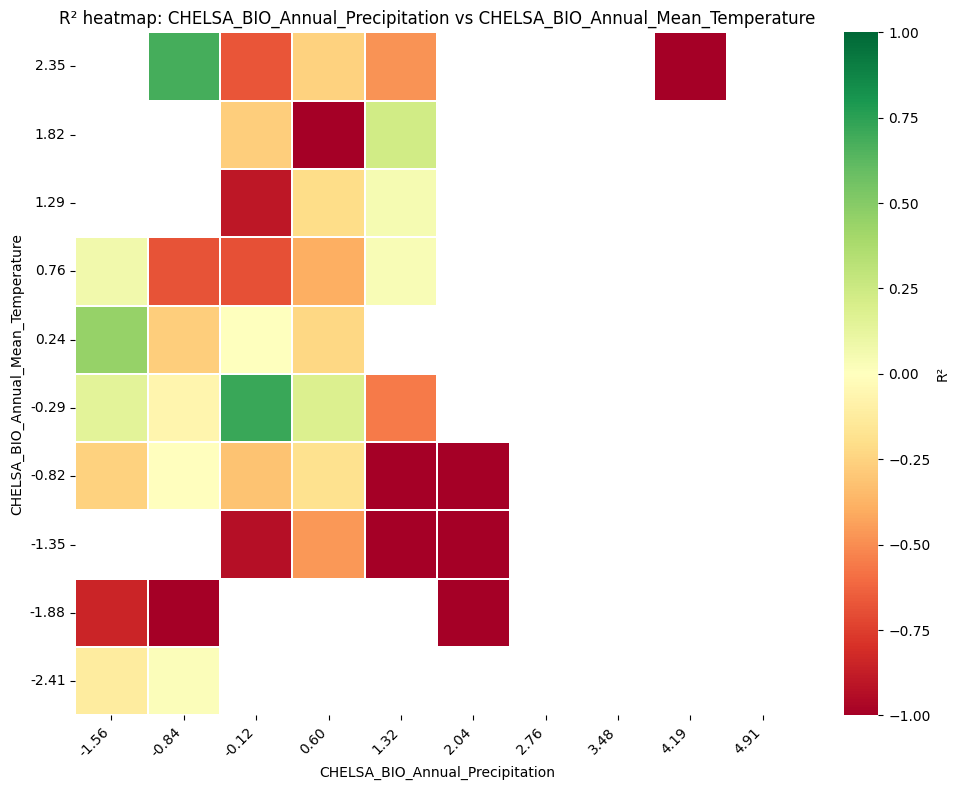

In [ ]:
plot_r2_heatmap(fd_reg, fX_test, fy_test, feature_x='CHELSA_BIO_Annual_Precipitation', feature_y='CHELSA_BIO_Annual_Mean_Temperature', bins=10)

### Testing the stuff


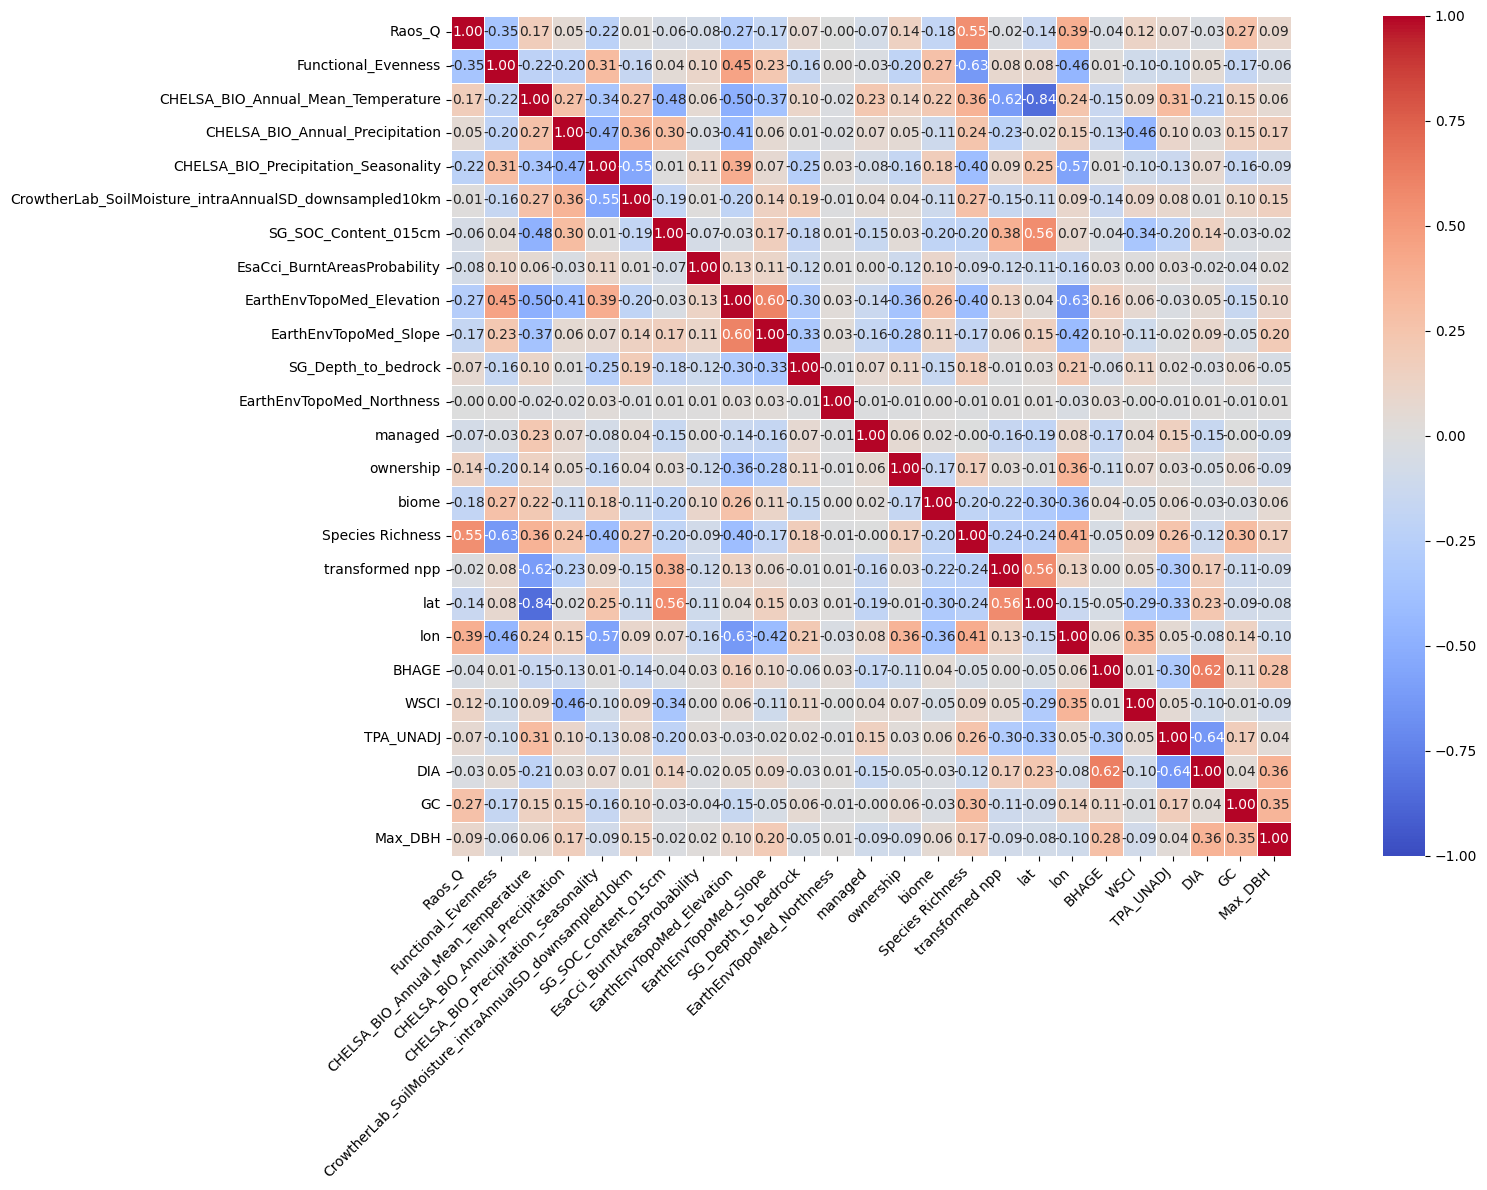

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = fd_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(20, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [54]:
def remove_highly_correlated(df, threshold=0.6):
    corr = df.corr(numeric_only=True).abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return df.drop(columns=to_drop)

fd_df_filtered = remove_highly_correlated(fd_df, threshold=0.55)
print(f"Dropped: {set(fd_df.columns) - set(fd_df_filtered.columns)}")

Dropped: {'lat', 'DIA', 'Species Richness', 'transformed npp', 'EarthEnvTopoMed_Slope', 'lon'}
